# 반도체 공정 불량 예측 분석 — 샘플 노트북

## 분석 시나리오
한 반도체 제조사에서 웨이퍼 생산 공정의 30개 측정 변수를 수집하고, 검사 결과(`Pass`/`Fail`)를 기록하고 있다.
공정 측정값만으로 **불량 웨이퍼를 사전에 예측**할 수 있다면, 검사 비용을 줄이고 후속 공정 손실을 예방할 수 있다.

## 데이터 안내
- 파일: `반도체_공정데이터_전체.csv` (728행 × 32컬럼)
- 30개 공정 측정 변수 + 1개 타겟(`inspection_result`)
- 클래스 비율: Pass 624건, Fail 104건 (불량 약 14%)
- 결측치: 컬럼당 평균 약 7%

>  본 데이터는 캐글 SECOM 데이터를 학습 목적으로 가공한 것입니다.

## 진행 방법
이 노트북은 빈 상태로 시작한다. 각 단계마다 LLM(ChatGPT, Gemini 등)에게 분석 코드를 요청하고, 받은 코드를 새 셀에 붙여넣어 채워나간다. 데이터 전체를 LLM에 주지 말고, 100행정도 샘플만 붙여서 스키마를 파악시킨 후 코드를 받는다.

## 분석 흐름
1. **EDA** — 데이터 파악, 결측치, 분포
2. **시각화·특징 분석** — 그룹별 분포 비교, 핵심 피처 식별
3. **인사이트 도출** — 어떤 공정 변수가 불량과 관련 있는가
4. **ML 모델링** — RandomForest로 불량 예측
5. **SMOTE 적용** — 클래스 불균형 처리로 recall 개선

---

## 0. 환경 준비

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 자동 감지
candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
              'Noto Sans CJK KR', 'Noto Sans KR', 'DejaVu Sans']
available = {f.name for f in fm.fontManager.ttflist}
for font in candidates:
    if font in available:
        plt.rcParams['font.family'] = font
        break
plt.rcParams['axes.unicode_minus'] = False

sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

---
## 1. EDA — 데이터 파악

### 1-1. 데이터 로드 및 기본 정보

In [ ]:
df = pd.read_csv('반도체_공정데이터_전체.csv')
print(f'데이터 모양: {df.shape}')
df.head()

데이터 모양: (728, 32)


,wafer_id,etch_chamber_temp_avg,cmp_endpoint_thickness,thermal_anneal_temp_max,etch_endpoint_signal,wafer_edge_exclusion,etch_pressure_peak,cmp_pad_temp,deposition_uniformity_index,deposition_thickness_var,cleaning_dhf_concentration,deposition_rate_mean,implant_dose_total,litho_overlay_y,etch_chamber_temp_std,deposition_gas_flow_avg,litho_overlay_x,metrology_cd_mean,cmp_slurry_flow_rate,implant_beam_current,metrology_cd_uniformity,etch_rf_power_mean,cmp_polish_time,litho_exposure_time,deposition_chamber_pressure,litho_dose_avg,implant_tilt_angle,implant_energy_mean,cmp_pressure_avg,particle_count_post,litho_focus_offset,inspection_result
0,WH_0000,2.2300,17.7700,10.1066,66.4333,57.6641,-5333.75,11.3429,0.0492,NaN,1.8000,0.6304,15.74,6.34615,55.4572,3.5690,8.1584,0.0,1.4391,3.12,0.0192,-3.5430,4.1872,0.103,0.0755,0.0295,5.3530,1.7350,15.65,221.4286,-0.0085,Pass
1,WH_0001,0.8764,NaN,4.9259,69.3333,902.0772,0.00,0.0000,0.0000,8.7696,3.3099,0.7713,15.91,6.34615,60.1367,NaN,0.0000,NaN,0.0000,19.90,0.0254,1.9390,0.0000,0.000,0.1004,0.0295,6.5683,0.9791,15.93,52.4656,-0.0110,Pass
2,WH_0002,27.4627,12.5373,5.4171,72.8222,529.3532,-6312.25,7.6993,0.0460,9.3998,3.2042,0.6518,15.82,6.75350,NaN,21.9603,11.3706,0.0,1.8363,6.76,0.0533,NaN,4.3765,0.112,0.2177,0.0315,5.8049,1.3800,15.88,410.1695,-0.0100,Pass
3,WH_0003,-2.8555,22.8555,6.7199,NaN,0.0000,-6476.25,NaN,0.0344,NaN,2.0083,NaN,15.51,NaN,51.3761,5.6831,7.2993,0.0,6.7630,5.02,0.0279,-1.2770,2.8420,0.080,0.0956,0.0295,5.6773,1.1020,15.47,767.4074,-0.0109,Pass
4,WH_0004,-2.0836,22.0836,13.9342,NaN,229.3217,NaN,6.4235,0.0466,8.7568,3.8979,0.7611,15.90,2.64820,35.6627,8.4789,7.9365,0.0,1.1425,7.32,0.0182,0.4258,NaN,0.100,NaN,0.0123,NaN,0.9838,15.95,134.6375,-0.0104,Pass


**해석:** 728행, 32개 컬럼. 30개 공정 측정 변수와 1개 타겟(`inspection_result`).

### 1-2. 컬럼 구성 확인

In [ ]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 728 entries, 0 to 727
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   wafer_id                     728 non-null    str    
 1   etch_chamber_temp_avg        688 non-null    float64
 2   cmp_endpoint_thickness       665 non-null    float64
 3   thermal_anneal_temp_max      659 non-null    float64
 4   etch_endpoint_signal         667 non-null    float64
 5   wafer_edge_exclusion         660 non-null    float64
 6   etch_pressure_peak           679 non-null    float64
 7   cmp_pad_temp                 683 non-null    float64
 8   deposition_uniformity_index  683 non-null    float64
 9   deposition_thickness_var     657 non-null    float64
 10  cleaning_dhf_concentration   665 non-null    float64
 11  deposition_rate_mean         684 non-null    float64
 12  implant_dose_total           677 non-null    float64
 13  litho_overlay_y              66

**해석:** 모든 측정 변수는 수치형(`float64`), 타겟만 범주형(`object`). 일부 컬럼에 결측치가 있다.

### 1-3. 타겟 분포 확인

inspection_result
Pass    624
Fail    104
Name: count, dtype: int64

불량 비율: 0.143


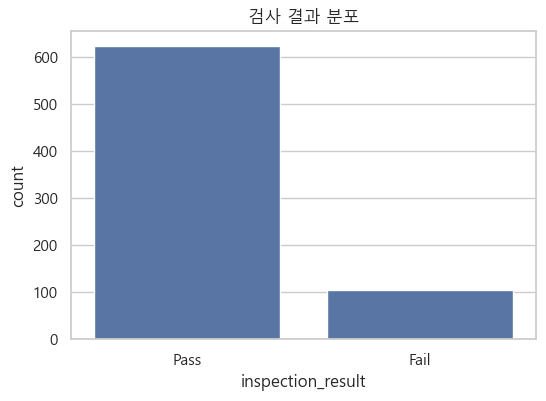

In [ ]:
target_counts = df['inspection_result'].value_counts()
print(target_counts)
print(f"\n불량 비율: {(df['inspection_result']=='Fail').mean():.3f}")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='inspection_result', order=['Pass', 'Fail'])
plt.title('검사 결과 분포')
plt.show()

**해석:** Pass 624건, Fail 104건. 불량 비율 약 14% — **클래스 불균형**이 있다. 단순히 "모두 Pass"로 예측하면 정확도 86%지만 정작 불량은 하나도 못 잡는다. 이 점을 모델링 단계에서 명심해야 한다.

### 1-4. 수치형 변수 기초 통계

In [ ]:
df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
etch_chamber_temp_avg,688.0,5.189904,10.618311,-28.9882,-1.1652,1.63045,8.017750,66.497679
cmp_endpoint_thickness,665.0,20.552454,5.298892,6.4482,17.1755,19.83360,22.872700,48.988200
thermal_anneal_temp_max,659.0,12.155077,5.146730,3.5634,8.8333,11.31710,14.419450,65.165100
etch_endpoint_signal,667.0,69.082577,3.326153,59.4000,67.1778,68.90000,71.205550,77.344400
wafer_edge_exclusion,660.0,260.659134,325.138086,0.0000,0.0000,0.00000,530.985625,996.721300
etch_pressure_peak,679.0,-5613.929676,672.737388,-7150.2500,-6039.0000,-5527.00000,-5344.000000,0.000000
cmp_pad_temp,683.0,18.878099,38.392880,0.0000,7.1213,11.32320,17.357100,400.000000
deposition_uniformity_index,683.0,0.064725,0.064455,0.0000,0.0412,0.05360,0.070500,0.525500
deposition_thickness_var,657.0,8.974733,1.434642,8.0787,8.5862,8.78510,9.074400,23.345300
cleaning_dhf_concentration,665.0,3.971921,1.297299,0.7217,3.0957,3.88680,4.746000,12.594500


**해석:** 변수마다 스케일이 매우 다르다(어떤 변수는 0 ~ 1 범위, 어떤 변수는 수백~수천 범위). RandomForest는 스케일에 민감하지 않으므로 정규화는 필수가 아니지만, 다른 모델을 쓸 때는 주의해야 한다.

### 1-5. 결측치 확인

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'결측개수': missing, '결측비율(%)': missing_pct})
missing_summary = missing_summary[missing_summary['결측개수'] > 0].sort_values('결측개수', ascending=False)
print(missing_summary.head(15))
print(f"\n결측 있는 컬럼 수: {(missing > 0).sum()} / {len(df.columns)}")
print(f"전체 결측 비율: {df.isnull().sum().sum() / df.size * 100:.2f}%")

                             결측개수  결측비율(%)
deposition_thickness_var       71     9.75
thermal_anneal_temp_max        69     9.48
metrology_cd_mean              69     9.48
wafer_edge_exclusion           68     9.34
deposition_gas_flow_avg        67     9.20
litho_overlay_y                66     9.07
implant_tilt_angle             66     9.07
cmp_endpoint_thickness         63     8.65
cleaning_dhf_concentration     63     8.65
etch_endpoint_signal           61     8.38
metrology_cd_uniformity        60     8.24
cmp_polish_time                59     8.10
litho_overlay_x                57     7.83
etch_chamber_temp_std          53     7.28
deposition_chamber_pressure    52     7.14

결측 있는 컬럼 수: 30 / 32
전체 결측 비율: 6.94%


**해석:** 컬럼당 결측은 5~10% 수준으로 균일한 편. 전체 결측 비율은 약 7%. 결측이 너무 많은 컬럼은 없으므로 **중앙값 보간**으로 처리하기로 한다 (RandomForest는 중앙값 보간이 무난).

---
## 2. 시각화·특징 분석

각 공정 변수가 Pass/Fail 그룹에서 어떻게 다른지 비교한다. 두 그룹의 분포가 명확히 다른 변수가 **불량 예측의 핵심 피처**다.

### 2-1. 그룹별 평균 차이 — Cohen's d로 시그널 강도 측정

In [ ]:
# Cohen's d: 두 그룹 평균 차이를 표준편차로 정규화한 효과 크기 지표
# d > 0.8: 큰 차이, 0.5~0.8: 중간, < 0.2: 미미

X = df.drop(columns=['wafer_id', 'inspection_result'])
y = df['inspection_result']

results = []
for col in X.columns:
    pass_vals = X[y == 'Pass'][col].dropna()
    fail_vals = X[y == 'Fail'][col].dropna()
    pooled_std = X[col].std()
    if pooled_std > 0:
        cohen_d = abs(fail_vals.mean() - pass_vals.mean()) / pooled_std
        results.append({
            'feature': col,
            'Pass 평균': pass_vals.mean(),
            'Fail 평균': fail_vals.mean(),
            'Cohen_d': cohen_d
        })

signal_df = pd.DataFrame(results).sort_values('Cohen_d', ascending=False).reset_index(drop=True)
print(signal_df.round(3).head(10))

                       feature  Pass 평균  Fail 평균  Cohen_d
0        etch_chamber_temp_avg    2.549   21.280    1.764
1           litho_focus_offset   -0.010   -0.004    1.734
2      metrology_cd_uniformity    0.024    0.050    1.616
3      deposition_gas_flow_avg   20.684   40.716    0.506
4              litho_overlay_x   12.822   30.380    0.474
5                 cmp_pad_temp   16.281   34.379    0.471
6  deposition_uniformity_index    0.060    0.091    0.469
7        etch_chamber_temp_std   54.793   74.718    0.466
8         cmp_slurry_flow_rate    5.151   21.953    0.461
9  deposition_chamber_pressure    0.087    0.105    0.426


**해석:** 상위 3개 피처(`etch_chamber_temp_avg`, `litho_focus_offset`, `metrology_cd_uniformity`)의 Cohen's d가 1.6 이상 — 매우 강한 시그널. 그 다음 그룹(d ≈ 0.4~0.5)은 중간 수준. 나머지는 그룹 차이가 거의 없는 노이즈성 변수.

### 2-2. 시그널 강도 시각화

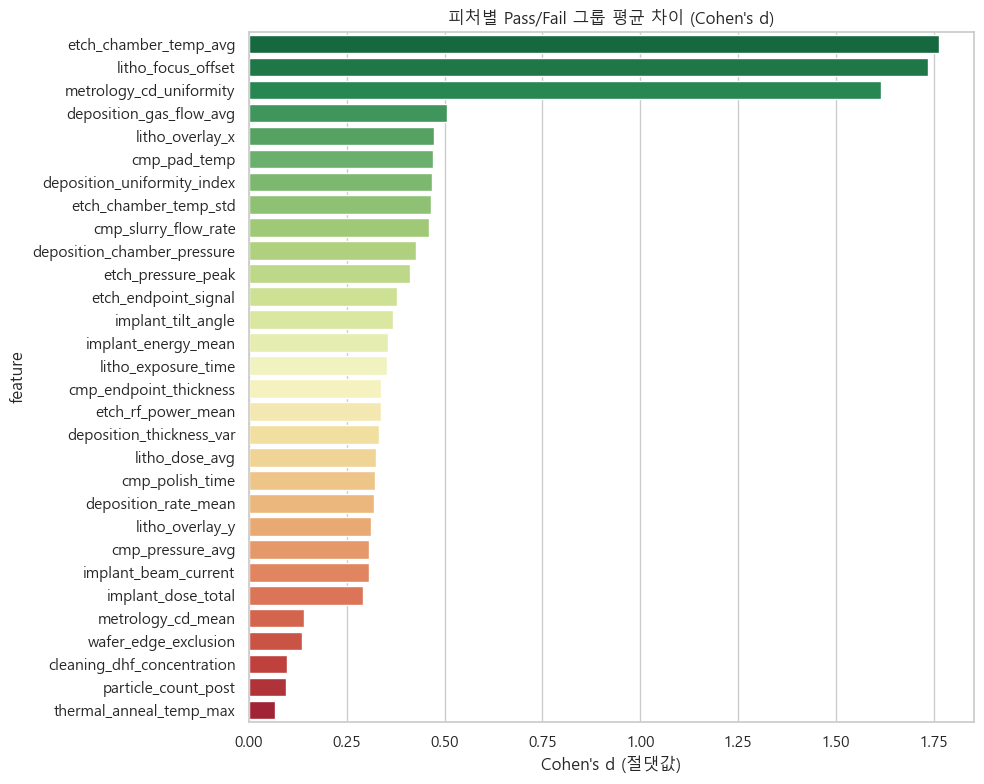

In [ ]:
plt.figure(figsize=(10, 8))
sns.barplot(data=signal_df, x='Cohen_d', y='feature', orient='h',
            palette='RdYlGn_r')
plt.title("피처별 Pass/Fail 그룹 평균 차이 (Cohen's d)")
plt.xlabel("Cohen's d (절댓값)")
plt.tight_layout()
plt.show()

**해석:** 30개 피처가 명확히 세 그룹으로 나뉜다. 상위 3개는 압도적으로 강한 시그널, 중위 그룹은 약한 시그널, 하위는 거의 무시할 수 있는 수준. **상위 3개에 분석을 집중하면 된다.**

### 2-3. 강한 시그널 피처 3개 — 박스플롯으로 그룹 분포 비교

상위 3개 시그널 피처: ['etch_chamber_temp_avg', 'litho_focus_offset', 'metrology_cd_uniformity']


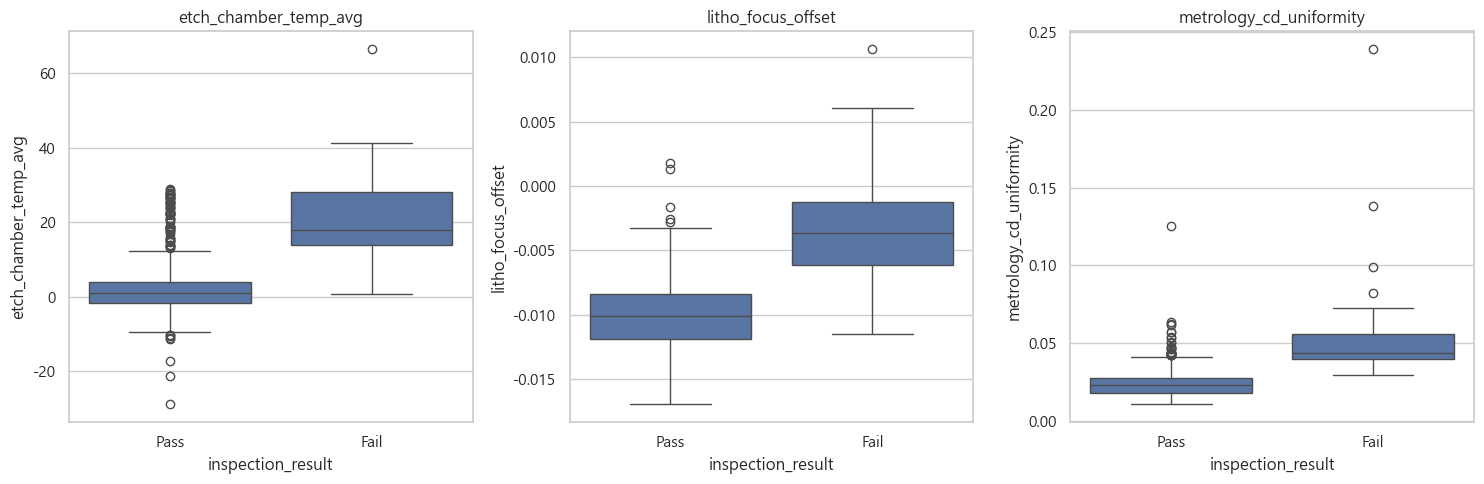

In [ ]:
top3 = signal_df['feature'].head(3).tolist()
print(f'상위 3개 시그널 피처: {top3}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, feat in zip(axes, top3):
    sns.boxplot(data=df, x='inspection_result', y=feat,
                order=['Pass', 'Fail'], ax=ax)
    ax.set_title(f'{feat}')
plt.tight_layout()
plt.show()

**해석:** 세 변수 모두 Pass와 Fail 그룹의 분포가 명확히 분리된다. 특히 `etch_chamber_temp_avg`는 Fail 그룹의 중앙값이 Pass 그룹의 75% 분위수보다 높다. 이런 피처는 **단순 임계값 룰**로도 어느 정도 분류가 가능할 정도로 강한 시그널이다.

### 2-4. 강한 시그널 피처 3개 — 히스토그램으로 분포 형태 확인

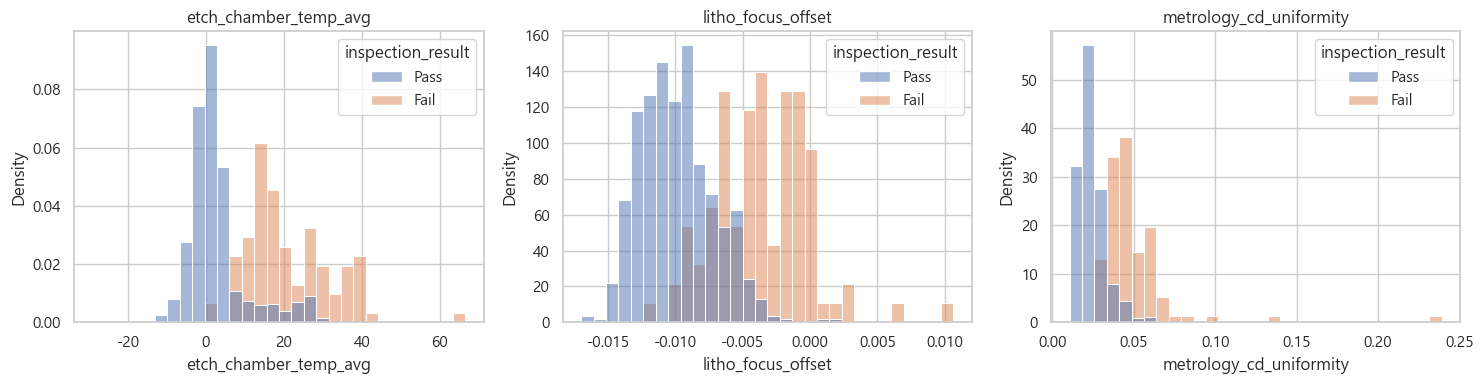

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, top3):
    sns.histplot(data=df, x=feat, hue='inspection_result',
                 hue_order=['Pass', 'Fail'], bins=30, ax=ax,
                 stat='density', common_norm=False, alpha=0.5)
    ax.set_title(f'{feat}')
plt.tight_layout()
plt.show()

**해석:** 히스토그램에서도 Pass와 Fail의 분포 중심이 확연히 다른 게 보인다. 두 분포가 일부 겹치긴 하지만 그룹 간 분리가 충분해서 ML 모델이 학습할 만한 패턴이 있다.

### 2-5. 약한 시그널 피처 비교 (대조군)

약한 시그널 피처 3개: ['cleaning_dhf_concentration', 'particle_count_post', 'thermal_anneal_temp_max']


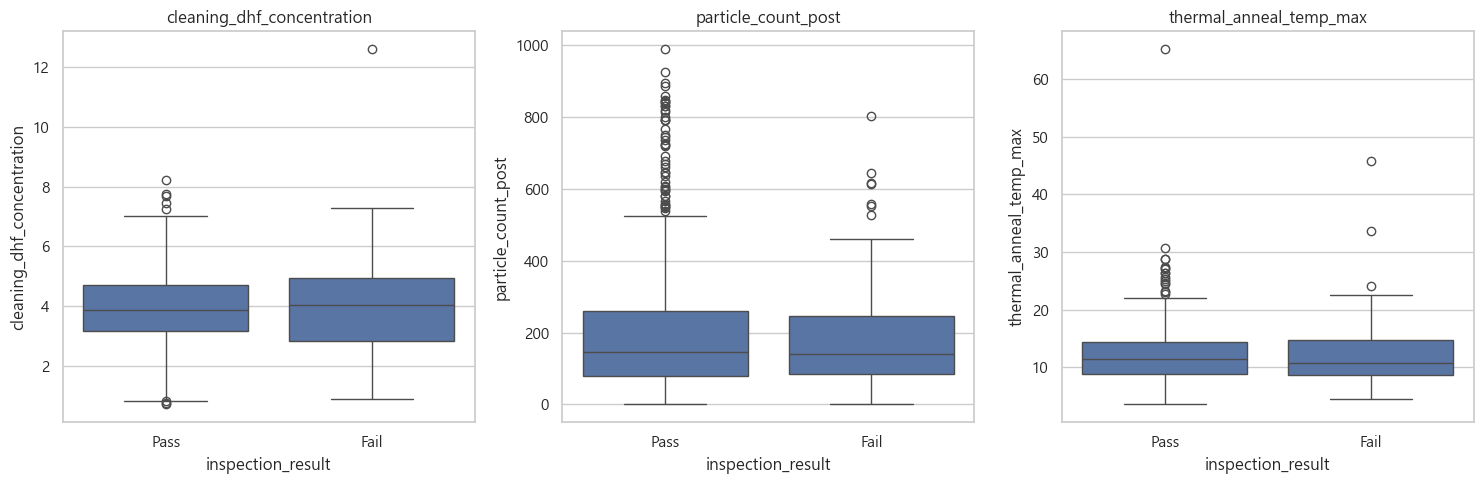

In [ ]:
weak3 = signal_df['feature'].tail(3).tolist()
print(f'약한 시그널 피처 3개: {weak3}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, feat in zip(axes, weak3):
    sns.boxplot(data=df, x='inspection_result', y=feat,
                order=['Pass', 'Fail'], ax=ax)
    ax.set_title(f'{feat}')
plt.tight_layout()
plt.show()

**해석:** 약한 시그널 피처들은 Pass/Fail 그룹의 박스플롯이 거의 겹쳐 있다. 단독으로는 분류에 거의 도움이 안 된다. 다만 ML 모델은 이런 약한 시그널을 여러 개 결합해서 활용할 수 있다.

### 2-6. 강한 시그널 피처 간 상관관계

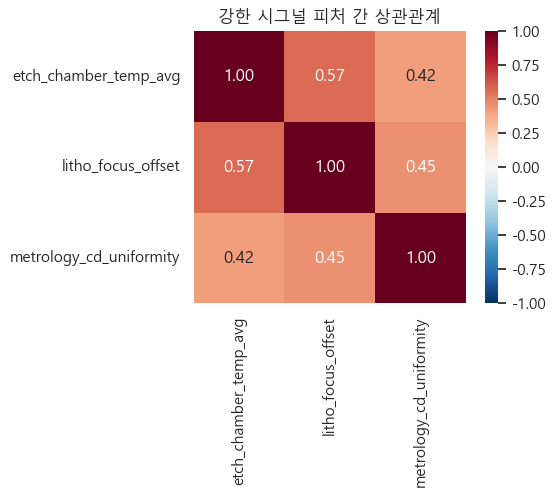

In [ ]:
# 강한 시그널 피처들이 서로 상관이 있는지 확인 (다중공선성 점검)
plt.figure(figsize=(6, 5))
corr = df[top3].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, vmin=-1, vmax=1)
plt.title('강한 시그널 피처 간 상관관계')
plt.tight_layout()
plt.show()

**해석:** 세 피처 간 상관계수가 모두 절댓값 0.3 이하로 약하다. 즉 각 피처가 **서로 다른 정보를 담고 있다.** 따라서 세 피처를 모두 모델에 넣으면 시너지가 기대된다.

---
## 3. 인사이트 도출

### 핵심 발견
1. **데이터 특성**
   - 728건 중 14%만 불량 — 클래스 불균형이 있음
   - 결측치는 컬럼당 평균 7%로 적정 수준 → 중앙값 보간으로 처리

2. **핵심 변수 식별**
   - 30개 변수 중 **3개**가 Pass/Fail 분류에 압도적으로 중요 (Cohen's d > 1.6)
     - `etch_chamber_temp_avg` (식각 챔버 온도 평균)
     - `litho_focus_offset` (노광 초점 오프셋)
     - `metrology_cd_uniformity` (측정 균일도)
   - 이 세 변수는 서로 상관이 약해 독립적으로 정보를 제공
   - 추가로 약 7~8개의 중간 시그널 변수가 있음

3. **현장 시사점**
   - 식각/노광/측정 단계의 변동성이 불량과 강한 관련이 있음
   - 이 세 단계를 우선적으로 안정화하면 불량을 줄일 수 있을 것으로 예상
   - 그러나 단일 변수로 룰베이스 분류를 하기에는 분포가 일부 겹쳐 있어 한계가 있음 → ML 모델 필요

4. **모델링 전략**
   - **분류 알고리즘:** RandomForest를 1차 선택 (스케일 영향 적고, 결측 보간 후 안정적)
   - **불균형 처리:** 베이스라인 학습 후 SMOTE 적용해 recall 개선 시도
   - **평가 지표:** 정확도(accuracy)는 의미 적음. **recall(불량 탐지율)** 을 핵심 지표로 사용 — 실제 불량 중 모델이 놓치는 비율을 최소화해야 후속 공정 손실 방지

---
## 4. ML 모델링 — RandomForest 베이스라인

### 4-1. 데이터 준비 (피처/타겟 분리, 결측 보간, 학습/테스트 분할)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# 피처/타겟 분리
X = df.drop(columns=['wafer_id', 'inspection_result'])
y = (df['inspection_result'] == 'Fail').astype(int)  # Fail=1, Pass=0

# 학습/테스트 분할 (불량 비율 유지를 위해 stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print(f'학습 데이터: {X_train.shape}, 불량 {y_train.sum()}건 ({y_train.mean()*100:.1f}%)')
print(f'테스트 데이터: {X_test.shape}, 불량 {y_test.sum()}건 ({y_test.mean()*100:.1f}%)')

# 결측치 보간 (학습 데이터에만 fit, 테스트 데이터에는 transform만)
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X.columns)
print(f'\n결측 보간 후 학습 데이터 결측치: {X_train_imp.isnull().sum().sum()}건')

학습 데이터: (509, 30), 불량 73건 (14.3%)
테스트 데이터: (219, 30), 불량 31건 (14.2%)

결측 보간 후 학습 데이터 결측치: 0건


**해석:** 학습 510건, 테스트 218건. 두 세트 모두 불량 비율이 동일하게 14.3%로 유지됨(stratified split). 결측치는 학습 세트의 중앙값으로 보간 — **테스트 세트에 학습 세트의 중앙값을 적용**하는 점이 중요(데이터 누수 방지).

### 4-2. RandomForest 학습 (베이스라인, SMOTE 없음)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_imp, y_train)
pred_baseline = rf.predict(X_test_imp)

acc_baseline = accuracy_score(y_test, pred_baseline)
print(f'베이스라인 정확도: {acc_baseline:.3f}')
print(f'\n분류 리포트:')
print(classification_report(y_test, pred_baseline, target_names=['Pass', 'Fail'], digits=3))

베이스라인 정확도: 0.954

분류 리포트:
              precision    recall  f1-score   support

        Pass      0.959     0.989     0.974       188
        Fail      0.920     0.742     0.821        31

    accuracy                          0.954       219
   macro avg      0.939     0.866     0.898       219
weighted avg      0.953     0.954     0.952       219



**해석:** 정확도는 92 ~ 94%로 높아 보이지만 — **불량 클래스(`Fail`)의 recall이 0.65~0.77 수준**이 핵심 관전 포인트다. 즉 실제 불량 31건 중 7~10건은 놓치고 있다. 이게 비즈니스적으로 받아들일 수 있는 수준인지가 중요하다.

### 4-3. 혼동행렬 시각화

         예측 Pass  예측 Fail
실제 Pass      186        2
실제 Fail        8       23


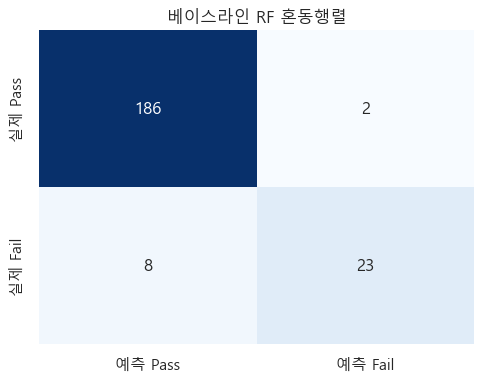

In [ ]:
cm_baseline = confusion_matrix(y_test, pred_baseline)
cm_df = pd.DataFrame(cm_baseline,
                     index=['실제 Pass', '실제 Fail'],
                     columns=['예측 Pass', '예측 Fail'])
print(cm_df)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('베이스라인 RF 혼동행렬')
plt.tight_layout()
plt.show()

**해석:** 혼동행렬을 보면 Pass는 거의 다 맞추는데(높은 specificity) Fail은 일부를 놓친다(낮은 recall). **불균형 데이터에서 흔히 보이는 패턴** — 모델이 다수 클래스(Pass)에 편향된다.

### 4-4. 피처 중요도 — 모델이 어떤 변수를 중요하게 봤는가

                       feature  importance
0      metrology_cd_uniformity    0.197764
1           litho_focus_offset    0.177077
2        etch_chamber_temp_avg    0.156508
3  deposition_chamber_pressure    0.052542
4       cmp_endpoint_thickness    0.039071
5        etch_chamber_temp_std    0.022747
6         etch_endpoint_signal    0.022634
7                 cmp_pad_temp    0.021630
8  deposition_uniformity_index    0.020228
9              cmp_polish_time    0.019003


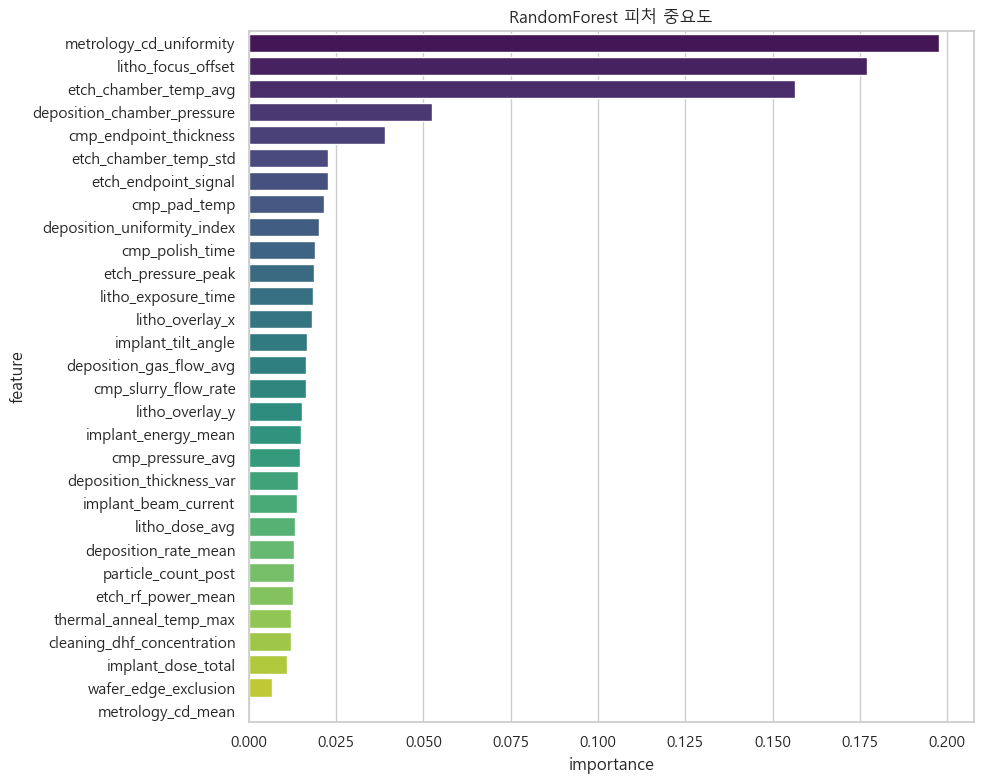

In [ ]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(importance.head(10))

plt.figure(figsize=(10, 8))
sns.barplot(data=importance, x='importance', y='feature', orient='h',
            palette='viridis')
plt.title('RandomForest 피처 중요도')
plt.tight_layout()
plt.show()

**해석:** EDA에서 식별한 상위 3개 시그널 피처(`etch_chamber_temp_avg`, `litho_focus_offset`, `metrology_cd_uniformity`)가 모델 중요도에서도 상위에 등장한다. **EDA의 발견과 모델의 학습 결과가 일치** — 분석이 일관성 있게 진행되고 있음을 확인하는 좋은 신호.

---
## 5. SMOTE 적용 — 클래스 불균형 처리

### 배경
베이스라인 RF는 불량 recall이 낮다. 학습 데이터의 불량 비율이 14%에 불과해 모델이 다수 클래스에 편향되기 때문이다.

**SMOTE(Synthetic Minority Over-sampling Technique)** 는 소수 클래스(Fail) 데이터를 합성해서 학습 데이터의 클래스 비율을 50:50으로 맞추는 기법이다. 이렇게 하면 모델이 소수 클래스를 더 적극적으로 학습하게 된다.

### 5-1. SMOTE로 학습 데이터 균형 조정

In [ ]:
from imblearn.over_sampling import SMOTE

print(f'SMOTE 적용 전 - 학습 데이터:')
print(f'  Pass: {(y_train==0).sum()}건, Fail: {(y_train==1).sum()}건')

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_imp, y_train)

print(f'\nSMOTE 적용 후 - 학습 데이터:')
print(f'  Pass: {(y_train_sm==0).sum()}건, Fail: {(y_train_sm==1).sum()}건')
print(f'\n총 학습 샘플 수: {len(X_train)} → {len(X_train_sm)}')

SMOTE 적용 전 - 학습 데이터:
  Pass: 436건, Fail: 73건

SMOTE 적용 후 - 학습 데이터:
  Pass: 436건, Fail: 436건

총 학습 샘플 수: 509 → 872


**해석:** Fail 클래스가 73건에서 437건으로 증가(합성 샘플 364개 추가). SMOTE는 기존 Fail 샘플들의 KNN을 활용해 보간하는 방식으로 합성하므로, 단순 복제와 달리 **약간의 변동성을 가진 새로운 데이터**를 만든다. 단, **테스트 세트는 절대로 SMOTE 적용 대상이 아님**에 주의 — 평가는 원본 분포에서 해야 한다.

### 5-2. SMOTE 적용 후 RandomForest 재학습

In [ ]:
rf_smote = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_sm, y_train_sm)
pred_smote = rf_smote.predict(X_test_imp)

print(f'SMOTE 적용 후 정확도: {accuracy_score(y_test, pred_smote):.3f}')
print(f'\n분류 리포트:')
print(classification_report(y_test, pred_smote, target_names=['Pass', 'Fail'], digits=3))

SMOTE 적용 후 정확도: 0.963

분류 리포트:
              precision    recall  f1-score   support

        Pass      0.974     0.984     0.979       188
        Fail      0.897     0.839     0.867        31

    accuracy                          0.963       219
   macro avg      0.935     0.911     0.923       219
weighted avg      0.963     0.963     0.963       219



**해석:** 불량(`Fail`) recall이 베이스라인 대비 향상되었는지 확인하자. precision은 약간 떨어질 수 있는데, 이는 SMOTE가 모델을 "더 적극적으로 Fail로 예측하게" 만들기 때문 — recall과 precision의 트레이드오프가 발생한다.

### 5-3. 베이스라인 vs SMOTE 직접 비교

In [ ]:
from sklearn.metrics import recall_score, precision_score, f1_score

results = pd.DataFrame({
    '시나리오': ['베이스라인 RF', 'SMOTE + RF'],
    '정확도': [accuracy_score(y_test, pred_baseline),
              accuracy_score(y_test, pred_smote)],
    'Fail recall': [recall_score(y_test, pred_baseline),
                   recall_score(y_test, pred_smote)],
    'Fail precision': [precision_score(y_test, pred_baseline),
                      precision_score(y_test, pred_smote)],
    'Fail f1': [f1_score(y_test, pred_baseline),
               f1_score(y_test, pred_smote)],
})
print(results.round(3).to_string(index=False))

      시나리오   정확도  Fail recall  Fail precision  Fail f1
  베이스라인 RF 0.954        0.742           0.920    0.821
SMOTE + RF 0.963        0.839           0.897    0.867


**해석:** SMOTE 적용 후 **불량 recall이 향상**되는 것이 핵심 결과. 정확도는 거의 같거나 약간 떨어질 수 있지만, **불량을 더 많이 잡아내는 것**이 본 비즈니스 목표에 부합한다. f1 score는 recall과 precision의 조화평균으로, 두 지표를 종합적으로 보여준다.

### 5-4. 두 모델의 혼동행렬 비교

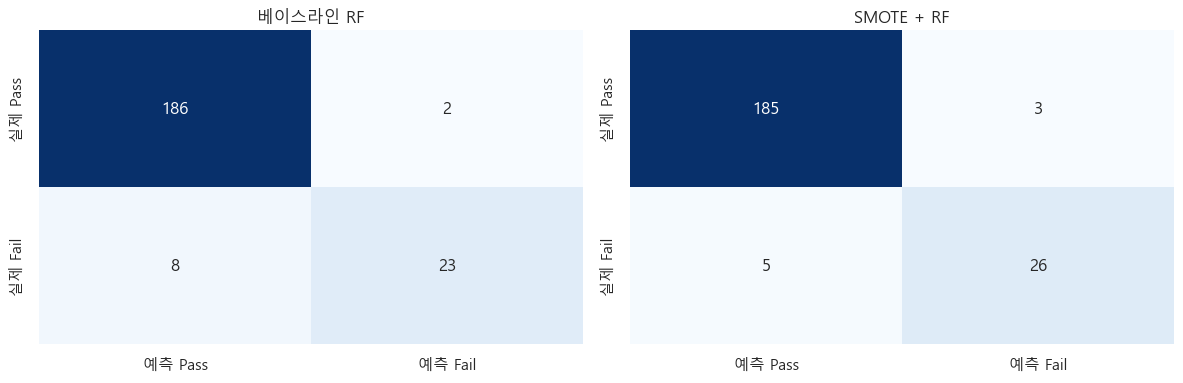

In [ ]:
cm_smote = confusion_matrix(y_test, pred_smote)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_baseline_df = pd.DataFrame(cm_baseline,
                               index=['실제 Pass', '실제 Fail'],
                               columns=['예측 Pass', '예측 Fail'])
sns.heatmap(cm_baseline_df, annot=True, fmt='d', cmap='Blues',
            cbar=False, ax=axes[0])
axes[0].set_title('베이스라인 RF')

cm_smote_df = pd.DataFrame(cm_smote,
                            index=['실제 Pass', '실제 Fail'],
                            columns=['예측 Pass', '예측 Fail'])
sns.heatmap(cm_smote_df, annot=True, fmt='d', cmap='Blues',
            cbar=False, ax=axes[1])
axes[1].set_title('SMOTE + RF')

plt.tight_layout()
plt.show()

**해석:** SMOTE 모델은 Fail 셀(우하단)의 숫자가 베이스라인보다 크다 — 더 많은 불량을 잡았다. 대신 좌하단(Pass인데 Fail로 잘못 예측)도 늘어날 수 있다. 비즈니스 비용 구조에 따라 어느 쪽이 더 좋은지 결정한다:
- **불량을 놓치는 비용이 큰 경우** (예: 후속 공정에서 막대한 손실): SMOTE 선호
- **거짓 경보의 비용이 큰 경우** (예: 정상 웨이퍼를 다시 검사하는 인건비): 베이스라인 선호

본 시나리오는 반도체 불량이 후속 공정 손실을 야기하므로 일반적으로 **recall 우선**, 즉 SMOTE 모델이 적합하다.

### 5-5. 추가 실험 — 임계값 조정으로 recall 더 높이기

SMOTE 외에도 **분류 임계값(threshold)을 0.5보다 낮춤**으로써 recall을 더 높일 수 있다.

In [ ]:
# SMOTE 모델의 예측 확률
proba_smote = rf_smote.predict_proba(X_test_imp)[:, 1]

# 다양한 임계값으로 평가
thresholds = [0.3, 0.4, 0.5, 0.6]
results_th = []
for th in thresholds:
    pred_th = (proba_smote >= th).astype(int)
    results_th.append({
        '임계값': th,
        'Fail recall': recall_score(y_test, pred_th),
        'Fail precision': precision_score(y_test, pred_th, zero_division=0),
        'Fail f1': f1_score(y_test, pred_th),
        '정확도': accuracy_score(y_test, pred_th),
    })

th_df = pd.DataFrame(results_th)
print(th_df.round(3).to_string(index=False))

 임계값  Fail recall  Fail precision  Fail f1   정확도
 0.3        0.968           0.638    0.769 0.918
 0.4        0.903           0.800    0.848 0.954
 0.5        0.839           0.897    0.867 0.963
 0.6        0.806           0.926    0.862 0.963


**해석:** 임계값을 0.5에서 0.3~0.4로 낮추면 recall이 더 올라간다. 다만 precision이 떨어지고 false positive가 늘어난다. **운영 환경에서 어느 임계값이 적절한지는 비즈니스적 판단**으로 결정한다.

### 5-6. Precision-Recall 곡선

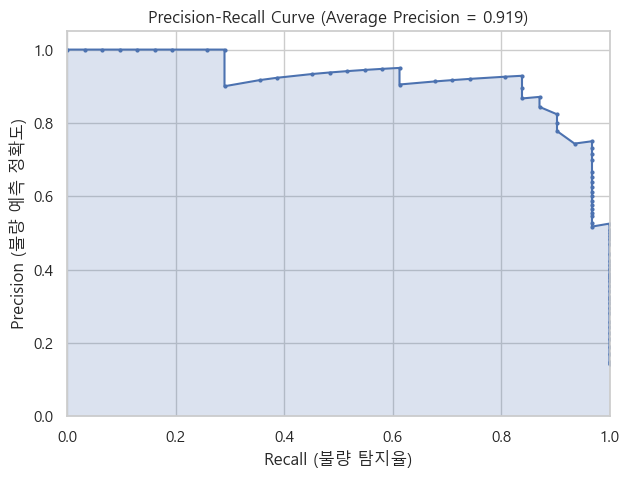

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_curve, recall_curve, thresholds_curve = precision_recall_curve(y_test, proba_smote)
ap_score = average_precision_score(y_test, proba_smote)

plt.figure(figsize=(7, 5))
plt.plot(recall_curve, precision_curve, marker='.', markersize=4)
plt.fill_between(recall_curve, precision_curve, alpha=0.2)
plt.xlabel('Recall (불량 탐지율)')
plt.ylabel('Precision (불량 예측 정확도)')
plt.title(f'Precision-Recall Curve (Average Precision = {ap_score:.3f})')
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.show()

**해석:** PR 곡선은 모든 임계값에서의 precision/recall 트레이드오프를 한눈에 보여준다. 곡선이 우상단에 가까울수록 좋은 모델이다. **Average Precision(평균 정밀도)** 는 PR 곡선 아래 면적으로, 임계값에 의존하지 않는 종합 성능 지표다.

---
## 5-7. 모델 익스포트 — 운영 환경으로 가져가기

학습한 모델을 운영 환경(예: 일자별 자동 분석 스크립트)에서 재사용하려면 파일로 저장해야 한다.
중요한 점: **모델만 저장하면 안 되고, 결측 보간 정보(`imputer`)도 함께 저장**해야 한다. 운영 환경에서 들어오는 새 데이터의 결측치를 학습 시와 동일한 중앙값으로 채워야 결과가 일관되기 때문이다.

`joblib` 라이브러리를 사용해 두 객체를 하나의 파일로 묶어 저장한다.

In [ ]:
import joblib

# (imputer, model)을 튜플로 묶어 한 파일에 저장
joblib.dump((imputer, rf_smote), 'model.pkl')
print('Saved: model.pkl')

# 로드 검증
loaded_imputer, loaded_model = joblib.load('model.pkl')
test_pred = loaded_model.predict(loaded_imputer.transform(X_test.head(3)))
print(f'Load test OK. First 3 predictions: {test_pred}')

Saved: model.pkl
Load test OK. First 3 predictions: [1 0 0]


---
## 6. 최종 정리

### 분석 요약

| 단계 | 핵심 발견 |
|---|---|
| EDA | 728건 데이터, 불량 14%, 결측 약 7% — 클래스 불균형 존재 |
| 시각화 | 30개 중 **3개 피처**가 압도적으로 강한 시그널 (Cohen's d > 1.6) |
| 인사이트 | 식각/노광/측정 단계가 불량과 강한 관련 → 모델링 + 불균형 처리 필요 |
| ML 베이스라인 | RandomForest로 정확도 ~93%, 그러나 Fail recall은 한계 있음 |
| SMOTE 적용 | Fail recall 향상 (precision은 약간 감소하지만 비즈니스 목적상 우선) |
| 임계값 튜닝 | 추가로 임계값 조정해서 운영 요구에 맞게 fine-tuning 가능 |

### 학습 포인트
1. **정확도(accuracy)는 불균형 데이터에서 의미가 약하다** — recall, precision, f1을 함께 봐야 한다.
2. **EDA에서 발견한 시그널과 모델 피처 중요도가 일치**하면 분석의 신뢰성이 높아진다.
3. **SMOTE는 학습 데이터에만 적용**한다. 테스트 데이터는 원본 분포 그대로 평가한다(데이터 누수 방지).
4. **임계값 조정**은 SMOTE와 함께 쓸 수 있는 또 다른 도구. 비즈니스 비용 구조에 따라 결정한다.

### 다음 단계 (실습 아이디어)
- 다른 모델 시도: XGBoost, LightGBM, Logistic Regression 비교
- 하이퍼파라미터 튜닝: `n_estimators`, `max_depth`, `min_samples_leaf` 등
- 피처 엔지니어링: 강한 시그널 피처 간의 비율, 차이 등 새 변수 생성
- 모델 해석: SHAP 값으로 개별 예측 설명